# Comparación y evaluación de modelos de Machine Learning

En este cuaderno vamos a trabajar sobre una etapa fundamental de cualquier proyecto de Machine Learning: la comparación de modelos.

Hasta ahora aprendimos a cargar datos, explorarlos, prepararlos, entrenar modelos y evaluar sus resultados. También vimos cómo los `Pipeline` nos permiten organizar el flujo completo de trabajo, integrando el preprocesamiento y el modelo en una misma estructura.

En esta clase vamos a unir esas ideas para responder una pregunta central:

**¿Cómo elegimos el modelo más adecuado para un problema concreto?**

Para hacerlo, no alcanza con mirar una sola métrica. Vamos a comparar distintos modelos utilizando varias herramientas de evaluación, como:

- métricas de clasificación;
- matriz de confusión;
- validación cruzada;
- curva ROC;
- AUC;
- visualizaciones comparativas.

El objetivo no será simplemente encontrar “el modelo que da mejor número”, sino aprender a justificar una decisión técnica a partir de evidencia.

## ¿Por qué comparar modelos?

Cuando resolvemos un problema de Machine Learning, rara vez existe un único modelo posible. Para un mismo conjunto de datos podríamos entrenar una regresión logística, un modelo KNN, un árbol de decisión, un random forest u otros algoritmos.

Cada modelo tiene fortalezas y limitaciones. Algunos son más simples de interpretar, otros pueden lograr mejores resultados, algunos necesitan escalado de variables y otros no, algunos son más rápidos y otros requieren más tiempo de entrenamiento.

Por eso, comparar modelos no significa solamente mirar cuál tiene mayor `accuracy`. Un buen análisis debe considerar varios aspectos:

- qué tan bien predice el modelo;
- qué tipo de errores comete;
- qué tan estable es su rendimiento;
- qué tan fácil es explicar sus decisiones;
- qué costo tendría equivocarse en cada tipo de caso;
- qué tan adecuado es para el contexto del problema.

En este cuaderno vamos a comparar varios modelos bajo condiciones equivalentes. Para eso, usaremos `Pipeline`, de modo que cada modelo tenga un flujo de trabajo claro, ordenado y reproducible.

## De los pipelines a la comparación de modelos

En el cuaderno anterior trabajamos con `Pipeline`, una herramienta de `scikit-learn` que permite encadenar pasos de procesamiento y modelado.

Un pipeline puede incluir, por ejemplo:

1. imputación de valores faltantes;
2. escalado de variables numéricas;
3. codificación de variables categóricas;
4. entrenamiento de un modelo.

Esto es especialmente importante porque evita aplicar transformaciones de manera desordenada o accidentalmente usar información del conjunto de prueba durante el entrenamiento.

En este cuaderno vamos a aprovechar esa lógica. En lugar de entrenar cada modelo por separado y repetir muchas líneas de código, construiremos un pipeline para cada modelo candidato.

La estructura general será:

```text
datos originales
↓
limpieza inicial mínima
↓
separación en entrenamiento y prueba
↓
preprocesamiento dentro del pipeline
↓
modelo
↓
evaluación
↓
comparación final
```

De esta manera, todos los modelos serán evaluados de forma más justa y consistente.

## Importación de librerías

Comenzamos importando las librerías que vamos a utilizar durante el cuaderno.

Usaremos `pandas` y `numpy` para trabajar con los datos, `matplotlib` para crear gráficos y varias herramientas de `scikit-learn` para construir pipelines, entrenar modelos y evaluar resultados.

Aunque al principio la lista de importaciones puede parecer extensa, cada grupo cumple una función concreta dentro del flujo de trabajo:

- carga y organización de datos;
- preprocesamiento;
- creación de pipelines;
- entrenamiento de modelos;
- evaluación y comparación.

In [55]:
# Importamos librerías generales para trabajar con datos
import pandas as pd
import numpy as np

# Importamos matplotlib para realizar gráficos
import matplotlib.pyplot as plt

# Importamos el dataset que vamos a utilizar
from sklearn.datasets import load_breast_cancer

# Herramientas para separar datos y validar modelos
from sklearn.model_selection import train_test_split, cross_val_score

# Herramientas para construir pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Herramientas de preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Modelos que vamos a comparar
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Métricas de evaluación para clasificación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Configuración general para que pandas muestre mejor las tablas
pd.set_option("display.max_columns", None)

## Dataset de trabajo

Para este cuaderno vamos a utilizar el dataset `breast_cancer`, incluido en `scikit-learn`.

Este dataset se usa habitualmente para problemas de clasificación binaria. El objetivo es predecir si un tumor es benigno o maligno a partir de distintas mediciones numéricas obtenidas sobre imágenes de células.

Elegimos este dataset porque nos permite trabajar con un problema donde la comparación de modelos tiene sentido. No solo nos interesa saber cuántos casos acierta el modelo en general, sino también qué tipo de errores comete.

En un contexto de salud, un falso negativo puede ser especialmente delicado: significaría que el modelo predice que un caso no es riesgoso cuando en realidad sí lo era.

De todos modos, trabajaremos este dataset con fines educativos. El objetivo no es construir una herramienta médica real, sino aprender a evaluar y comparar modelos de clasificación.

In [56]:
# Cargamos el dataset desde scikit-learn
datos = load_breast_cancer()

# Convertimos las variables predictoras en un DataFrame de pandas
df = pd.DataFrame(datos.data, columns=datos.feature_names)

# Agregamos la variable objetivo al DataFrame
df["objetivo"] = datos.target

# Mostramos las primeras filas
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,objetivo
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Al observar las primeras filas vemos que el dataset contiene muchas columnas numéricas. Cada una representa una medición diferente relacionada con las características del tumor.

La columna `objetivo` es la variable que queremos predecir. En este dataset, las clases están codificadas de la siguiente manera:

- `0`: tumor maligno.
- `1`: tumor benigno.

Esto significa que estamos frente a un problema de **clasificación binaria**, porque el modelo debe elegir entre dos clases posibles.

A partir de estas variables, vamos a entrenar distintos modelos y luego compararemos su rendimiento.

## Exploración inicial del dataset

Antes de construir modelos, necesitamos conocer la estructura general de los datos.

En esta etapa vamos a revisar:

- cuántas filas y columnas tiene el dataset;
- qué tipo de datos contiene cada columna;
- si hay valores faltantes;
- cómo está distribuida la variable objetivo.

Esta revisión inicial nos ayuda a decidir qué tipo de preprocesamiento necesitamos aplicar.

In [57]:
# Revisamos la cantidad de filas y columnas del DataFrame
df.shape

(569, 31)

El resultado anterior nos indica que el dataset tiene 569 filas y 31 columnas.

De esas 31 columnas, 30 corresponden a variables predictoras y 1 corresponde a la variable objetivo.

In [58]:
# Revisamos información general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

Con `df.info()` podemos observar el tipo de dato de cada columna y la cantidad de valores no nulos.

En este caso, todas las variables predictoras son numéricas. Esto simplifica el preprocesamiento, porque no necesitamos codificar variables categóricas.

De todos modos, vamos a mantener la lógica de pipeline porque nos interesa construir un flujo ordenado y reutilizable. En otros datasets, este mismo esquema podría ampliarse para incluir variables categóricas, texto, fechas u otros tipos de datos.

In [59]:
# Revisamos si existen valores faltantes en cada columna
df.isna().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


El dataset no presenta valores faltantes. Sin embargo, más adelante igualmente vamos a incluir un imputador dentro del pipeline.

Esto puede parecer innecesario para este caso particular, pero tiene un valor práctico: nos permite construir un flujo más robusto. Si en el futuro usamos un dataset similar con algunos valores faltantes, el pipeline ya estará preparado para resolver ese problema sin modificar toda la estructura del código.

Además, incluir el imputador dentro del pipeline ayuda a reforzar una buena práctica: las transformaciones que calculan información a partir de los datos deben ajustarse con el conjunto de entrenamiento, no con todo el dataset completo.

In [60]:
# Observamos la distribución de la variable objetivo
df["objetivo"].value_counts()

,count
objetivo,
1,357
0,212


El resultado muestra cuántos casos hay de cada clase.

Recordemos que:

- `0` significa tumor maligno;
- `1` significa tumor benigno.

Esta distribución es importante porque, si una clase aparece mucho más que la otra, la métrica `accuracy` puede resultar engañosa. Un modelo podría obtener un porcentaje alto de aciertos simplemente prediciendo con frecuencia la clase mayoritaria.

Por eso, en este cuaderno no vamos a evaluar los modelos solo con `accuracy`, sino también con otras métricas como `precision`, `recall`, `F1-score`, matriz de confusión, curva ROC y AUC.

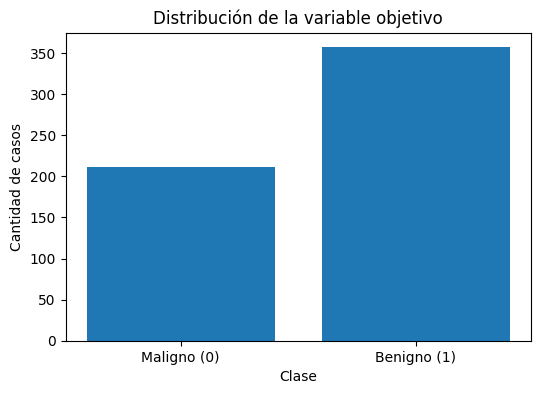

In [61]:
# Graficamos la distribución de la variable objetivo

conteo_clases = df["objetivo"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Maligno (0)", "Benigno (1)"], conteo_clases.values)
plt.title("Distribución de la variable objetivo")
plt.xlabel("Clase")
plt.ylabel("Cantidad de casos")
plt.show()

La distribución de clases muestra que hay más casos benignos que malignos:

- `357` casos benignos.
- `212` casos malignos.

Esto significa que el dataset no está perfectamente balanceado. La diferencia no es extrema, pero sí es suficiente para tener cuidado al interpretar los resultados.

Por ejemplo, si un modelo tendiera a predecir con demasiada frecuencia la clase mayoritaria, podría lograr una `accuracy` aparentemente aceptable, pero fallar en casos importantes.

En este problema, además, no todos los errores tienen el mismo peso. Clasificar un tumor maligno como benigno sería un error especialmente delicado. En términos de matriz de confusión, ese caso sería un **falso benigno**, es decir, un caso maligno que el modelo no logró detectar correctamente.

Por eso, más adelante vamos a mirar varias métricas y no solamente el porcentaje general de aciertos.

## Separación entre variables predictoras y variable objetivo

Antes de entrenar modelos, tenemos que separar el dataset en dos partes:

- `X`: contiene las variables predictoras, es decir, las columnas que el modelo usará para aprender.
- `y`: contiene la variable objetivo, es decir, aquello que queremos predecir.

En este caso, todas las columnas excepto `objetivo` serán parte de `X`.

La columna `objetivo` será nuestra variable `y`.

In [62]:
# Separamos las variables predictoras y la variable objetivo

X = df.drop(columns=["objetivo"])
y = df["objetivo"]

# Revisamos las dimensiones de cada parte
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (569, 30)
Dimensiones de y: (569,)


## Separación en entrenamiento y prueba

Ahora vamos a dividir los datos en dos conjuntos:

- un conjunto de entrenamiento, que el modelo usará para aprender;
- un conjunto de prueba, que usaremos al final para evaluar qué tan bien generaliza el modelo ante datos no vistos.

Esta separación es muy importante. Las transformaciones del pipeline, como el escalado o la imputación, deberán ajustarse usando solamente el conjunto de entrenamiento.

Además, usaremos el parámetro `stratify=y`. Esto permite conservar una proporción similar de casos benignos y malignos tanto en entrenamiento como en prueba.

In [63]:
# Separamos los datos en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Revisamos las dimensiones obtenidas
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)


La separación generó 455 registros para entrenamiento y 114 registros para prueba.

A partir de este punto debemos tener especial cuidado: cualquier transformación que aprenda información de los datos debe ajustarse solamente con `X_train`.

Por ejemplo, si calculamos una media, una mediana, una desviación estándar o una escala usando todo el dataset, estaríamos dejando que el conjunto de prueba influya indirectamente en el entrenamiento. Eso produciría **data leakage**.

Para evitarlo, vamos a colocar las transformaciones de preparación dentro de un `Pipeline`. De esa manera, `scikit-learn` se encargará de ajustar esas transformaciones solo con los datos de entrenamiento y luego aplicarlas de forma consistente sobre los datos de prueba.

## Construcción del preprocesamiento

En este dataset todas las variables predictoras son numéricas. Por eso, el preprocesamiento será más simple que en otros casos donde también hay variables categóricas.

Aun así, vamos a construir un pipeline de preprocesamiento para las columnas numéricas. Este pipeline incluirá dos pasos:

1. `SimpleImputer`: completa valores faltantes usando la mediana.
2. `StandardScaler`: escala las variables para que tengan una escala comparable.

Aunque este dataset no tiene valores faltantes, incluimos el imputador para mantener un flujo de trabajo robusto y reutilizable.

El escalado sí es especialmente importante para algunos modelos, como KNN y regresión logística, porque estos modelos pueden verse afectados por la escala de las variables.

In [64]:
# Identificamos las columnas numéricas

columnas_numericas = X_train.columns

# Creamos el pipeline para las variables numéricas
pipeline_numericas = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", StandardScaler())
    ]
)

# Mostramos la cantidad de columnas numéricas
print("Cantidad de columnas numéricas:", len(columnas_numericas))

Cantidad de columnas numéricas: 30


## Integración del preprocesamiento con `ColumnTransformer`

Ahora vamos a crear el objeto `preprocesamiento`.

Para eso usaremos `ColumnTransformer`, una herramienta que permite aplicar distintas transformaciones a distintos grupos de columnas.

En este caso solo tenemos columnas numéricas, por lo que el `ColumnTransformer` aplicará el `pipeline_numericas` a todas las variables predictoras.

Aunque acá parezca una estructura más grande de lo necesario, es una buena práctica porque nos deja preparado el flujo para datasets más complejos. Si en otro problema tuviéramos variables categóricas, podríamos agregar otro pipeline dentro del mismo `ColumnTransformer`.

In [65]:
# Creamos el preprocesamiento general

preprocesamiento = ColumnTransformer(
    transformers=[
        ("numericas", pipeline_numericas, columnas_numericas)
    ]
)

preprocesamiento

ColumnTransformer(transformers=[('numericas',
                                 Pipeline(steps=[('imputador',
                                                  SimpleImputer(strategy='median')),
                                                 ('escalador',
                                                  StandardScaler())]),
                                 Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object'))])

El objeto `preprocesamiento` ya quedó definido, pero todavía no se aplicó sobre los datos.

Esto es importante: hasta ahora solo construimos la estructura del flujo. El imputador todavía no calculó medianas y el escalador todavía no calculó medias ni desviaciones estándar.

Esas operaciones recién ocurrirán cuando entrenemos un pipeline completo con `.fit()`.

Más adelante, cuando hagamos algo como:

```python
pipeline.fit(X_train, y_train)
```

`scikit-learn` ajustará el preprocesamiento usando solamente `X_train` y luego entrenará el modelo correspondiente.

Esta es una de las principales ventajas de trabajar con pipelines: nos permite definir el proceso completo, pero evita aplicar transformaciones antes de tiempo o de forma desordenada.

## Construcción de los modelos candidatos

Ahora vamos a definir los modelos que queremos comparar.

Trabajaremos con cuatro algoritmos ya conocidos:

- `LogisticRegression`: un modelo lineal, simple e interpretable.
- `KNeighborsClassifier`: un modelo basado en la cercanía entre registros.
- `DecisionTreeClassifier`: un árbol de decisión, capaz de capturar relaciones no lineales.
- `RandomForestClassifier`: un ensamble de muchos árboles de decisión.

La idea no es entrenarlos todavía, sino guardarlos en una estructura común para poder construir luego un pipeline completo para cada uno.

Esto nos permitirá comparar todos los modelos bajo una misma lógica de trabajo.

In [66]:
# Definimos los modelos candidatos que vamos a comparar

modelos = {
    "Regresión logística": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Árbol de decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Mostramos los nombres de los modelos definidos
modelos.keys()

dict_keys(['Regresión logística', 'KNN', 'Árbol de decisión', 'Random Forest'])

## Creación de un pipeline para cada modelo

Ya tenemos definidos los modelos candidatos. Ahora vamos a construir un pipeline completo para cada uno.

Cada pipeline tendrá dos grandes pasos:

1. `preprocesamiento`: aplica las transformaciones necesarias sobre las variables predictoras.
2. `modelo`: entrena el algoritmo correspondiente.

De esta manera, todos los modelos van a recibir los datos preparados con el mismo criterio.

Esto es importante para que la comparación sea más justa. Si cada modelo recibiera datos transformados de una manera distinta, no sabríamos si las diferencias de rendimiento se deben al algoritmo o al preprocesamiento aplicado.

In [67]:
# Creamos un pipeline completo para cada modelo

pipelines = {}

for nombre_modelo, modelo in modelos.items():
    pipelines[nombre_modelo] = Pipeline(
        steps=[
            ("preprocesamiento", preprocesamiento),
            ("modelo", modelo)
        ]
    )

# Mostramos los nombres de los pipelines creados
pipelines.keys()

dict_keys(['Regresión logística', 'KNN', 'Árbol de decisión', 'Random Forest'])

Los pipelines ya fueron creados, pero todavía no fueron entrenados.

Hasta este punto tenemos preparada la estructura de trabajo:

```text
datos de entrada
↓
preprocesamiento
↓
modelo
↓
predicción
```

Cada pipeline tiene el mismo paso de preprocesamiento, pero cambia el algoritmo final.

En la siguiente etapa vamos a entrenar cada pipeline con los datos de entrenamiento y luego evaluarlo con los datos de prueba.

## Función para entrenar y evaluar modelos

Como vamos a comparar varios modelos, conviene evitar repetir el mismo código una y otra vez.

Para eso vamos a crear una función llamada `evaluar_modelo()`.

Esta función recibirá:

- el nombre del modelo;
- el pipeline correspondiente;
- los datos de entrenamiento;
- los datos de prueba.

Luego hará lo siguiente:

1. entrenará el pipeline con `X_train` e `y_train`;
2. generará predicciones sobre `X_test`;
3. calculará distintas métricas de clasificación;
4. devolverá los resultados en forma de diccionario.

Más adelante usaremos esos diccionarios para construir una tabla comparativa.

In [68]:
# Creamos una función para entrenar y evaluar un modelo

def evaluar_modelo(nombre_modelo, pipeline, X_train, X_test, y_train, y_test):
    """
    Entrena un pipeline y calcula métricas básicas de clasificación.

    En este problema vamos a considerar como clase de mayor interés
    a la clase 0, que representa los casos malignos.
    """

    # Entrenamos el pipeline completo:
    # primero se ajusta el preprocesamiento y luego se entrena el modelo.
    pipeline.fit(X_train, y_train)

    # Generamos predicciones sobre el conjunto de prueba.
    y_pred = pipeline.predict(X_test)

    # Calculamos métricas de clasificación.
    # Usamos pos_label=0 porque nos interesa especialmente detectar casos malignos.
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

    # Devolvemos los resultados en un diccionario.
    resultados = {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

    return resultados

La función `evaluar_modelo()` todavía no ejecuta ninguna evaluación por sí sola. Solo deja preparada una herramienta que podremos reutilizar con todos los pipelines.

Un detalle importante es que usamos `pos_label=0` en las métricas `precision`, `recall` y `F1-score`.

Esto se debe a que, en este dataset, la clase `0` representa los casos malignos. Como ese tipo de caso es el más delicado desde el punto de vista del problema, vamos a evaluar especialmente qué tan bien cada modelo logra detectarlo.

Dicho de otra manera: no solo queremos saber si el modelo acierta mucho en general, sino si es capaz de reconocer correctamente los casos malignos.

## Entrenamiento y evaluación de todos los modelos

Ahora vamos a recorrer el diccionario `pipelines`.

Para cada modelo vamos a:

1. tomar su pipeline correspondiente;
2. entrenarlo con los datos de entrenamiento;
3. evaluarlo con los datos de prueba;
4. guardar sus métricas en una lista.

Al finalizar, convertiremos esa lista en un DataFrame para comparar los resultados de manera más cómoda.

In [69]:
# Entrenamos y evaluamos todos los modelos

resultados = []

for nombre_modelo, pipeline in pipelines.items():
    resultado = evaluar_modelo(
        nombre_modelo=nombre_modelo,
        pipeline=pipeline,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test
    )

    resultados.append(resultado)

# Convertimos los resultados en un DataFrame
df_resultados = pd.DataFrame(resultados)

# Mostramos la tabla comparativa inicial
df_resultados

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión logística,0.982456,0.976190,0.976190,0.976190
1,KNN,0.956140,0.951220,0.928571,0.939759
2,Árbol de decisión,0.912281,0.847826,0.928571,0.886364
3,Random Forest,0.956140,0.951220,0.928571,0.939759


La tabla anterior muestra una primera comparación entre los modelos.

En esta evaluación inicial, la **regresión logística** obtiene los mejores valores en las cuatro métricas observadas:

- `Accuracy`
- `Precision`
- `Recall`
- `F1-score`

Esto significa que, sobre el conjunto de prueba, fue el modelo con mejor rendimiento general y también el que mejor logró detectar la clase de interés, que en este caso son los tumores malignos (`0`).

Sin embargo, todavía no deberíamos elegir un modelo solamente con esta tabla. Estos resultados provienen de una única separación entre entrenamiento y prueba. Para tomar una decisión más sólida, necesitamos seguir analizando.

En las próximas secciones vamos a incorporar otras herramientas:

- el reporte completo de clasificación;
- la matriz de confusión;
- la validación cruzada;
- la curva ROC;
- el valor AUC.

Cada una de estas herramientas nos permitirá observar el comportamiento de los modelos desde una perspectiva diferente.

## Reporte de clasificación

La tabla comparativa anterior resume algunas métricas principales, pero también es útil observar el reporte completo de clasificación.

El `classification_report` muestra las métricas separadas por clase. Esto nos permite ver si el modelo funciona de manera equilibrada o si predice mejor una clase que la otra.

En este problema tenemos dos clases:

- `0`: tumor maligno.
- `1`: tumor benigno.

Recordemos que los casos malignos son especialmente importantes, porque un error en esa clase puede tener mayor impacto.

In [70]:
# Mostramos el reporte de clasificación para cada modelo

for nombre_modelo, pipeline in pipelines.items():

    # Generamos predicciones con el pipeline ya entrenado anteriormente
    y_pred = pipeline.predict(X_test)

    print("=" * 60)
    print(nombre_modelo)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Maligno (0)", "Benigno (1)"],
            zero_division=0
        )
    )

Regresión logística
              precision    recall  f1-score   support

 Maligno (0)       0.98      0.98      0.98        42
 Benigno (1)       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

KNN
              precision    recall  f1-score   support

 Maligno (0)       0.95      0.93      0.94        42
 Benigno (1)       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Árbol de decisión
              precision    recall  f1-score   support

 Maligno (0)       0.85      0.93      0.89        42
 Benigno (1)       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.9

El reporte de clasificación permite observar con más detalle cómo se comporta cada modelo en cada clase.

En el caso de la **regresión logística**, los valores son muy altos tanto para tumores malignos como para tumores benignos. Esto indica un comportamiento bastante equilibrado.

En **KNN** y **Random Forest**, los resultados también son buenos, aunque el `recall` para la clase maligna es un poco menor. Esto significa que dejaron sin detectar algunos casos malignos más que la regresión logística.

El **árbol de decisión** tiene un comportamiento interesante: mantiene un buen `recall` para la clase maligna, pero su `precision` es menor. Esto quiere decir que detecta una buena cantidad de casos malignos, pero también clasifica como malignos algunos casos que en realidad eran benignos.

Esta diferencia es importante porque nos muestra que no todos los errores son iguales. Según el contexto, puede ser preferible un modelo que detecte más casos malignos aunque genere algunas falsas alarmas, o un modelo que sea más preciso al marcar un caso como maligno.

Para entender mejor estos errores, en la siguiente sección vamos a trabajar con la **matriz de confusión**.

## Matriz de confusión

La matriz de confusión nos permite observar no solo cuántas predicciones fueron correctas, sino también **cómo se equivocó el modelo**.

En un problema de clasificación binaria, la matriz compara los valores reales con los valores predichos.

En este caso:

- `0` representa tumor maligno.
- `1` representa tumor benigno.

Por eso, un error especialmente delicado sería que un caso real maligno (`0`) sea predicho como benigno (`1`). Ese tipo de error significa que el modelo no detectó correctamente un caso importante.

A continuación vamos a graficar la matriz de confusión de cada modelo para comparar visualmente sus errores.

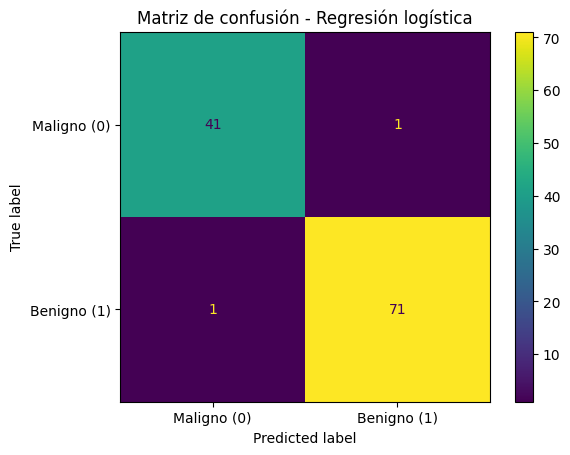

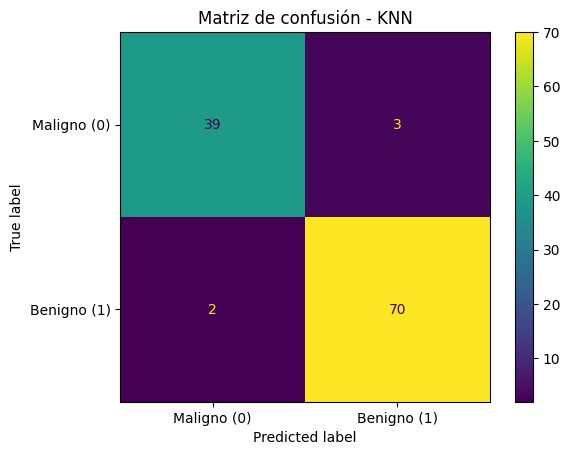

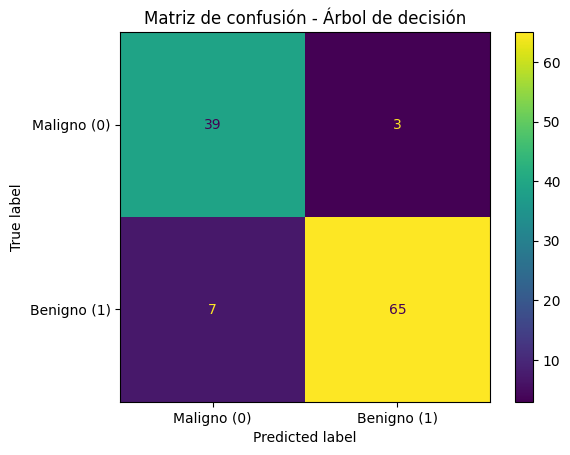

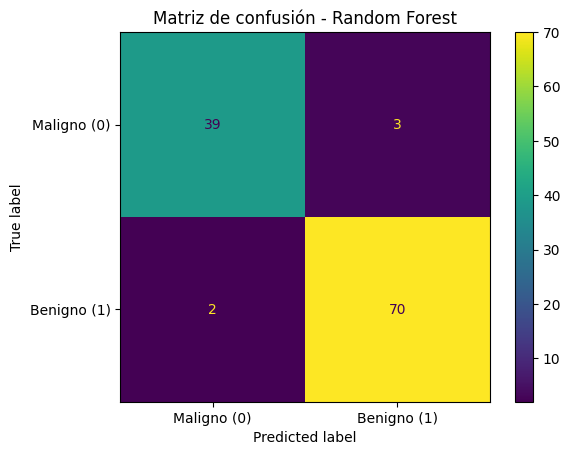

In [71]:
# Graficamos la matriz de confusión de cada modelo

for nombre_modelo, pipeline in pipelines.items():

    # Generamos predicciones sobre el conjunto de prueba
    y_pred = pipeline.predict(X_test)

    # Calculamos la matriz de confusión
    matriz = confusion_matrix(y_test, y_pred)

    # Creamos el gráfico
    display = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=["Maligno (0)", "Benigno (1)"]
    )

    display.plot()
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.show()

Al observar las matrices de confusión podemos analizar los errores de cada modelo con mayor claridad.

La **regresión logística** fue el modelo con menor cantidad de errores: clasificó correctamente 41 de los 42 casos malignos y 71 de los 72 casos benignos. Solo cometió 2 errores en total.

**KNN** clasificó correctamente 39 de los 42 casos malignos y 70 de los 72 casos benignos. Cometió 5 errores en total.

El **árbol de decisión** también detectó correctamente 39 de los 42 casos malignos, pero tuvo más errores al clasificar casos benignos: 7 casos benignos fueron predichos como malignos. En total cometió 10 errores.

**Random Forest** tuvo, en esta ejecución, el mismo comportamiento que KNN: 39 casos malignos correctamente detectados, 70 casos benignos correctamente clasificados y 5 errores totales.

La matriz de confusión nos permite ver algo que no siempre se nota con una única métrica general: algunos modelos pueden equivocarse más en una clase que en otra.

En este problema, nos interesa especialmente observar cuántos casos malignos fueron clasificados como benignos. Ese error aparece en la primera fila y segunda columna de la matriz. En términos del problema, representa casos malignos que el modelo no detectó correctamente.

## Visualización comparativa de métricas

Hasta ahora vimos los resultados en tablas y reportes de texto. Eso es útil, pero cuando comparamos varios modelos también conviene usar gráficos.

Una visualización nos permite detectar rápidamente qué modelos tienen mejor rendimiento y en qué métricas se diferencian.

En la siguiente celda vamos a graficar las métricas principales que calculamos hasta ahora:

- `Accuracy`
- `Precision`
- `Recall`
- `F1-score`

Recordemos que `Precision`, `Recall` y `F1-score` fueron calculadas tomando como clase positiva de interés a la clase `0`, es decir, los tumores malignos.

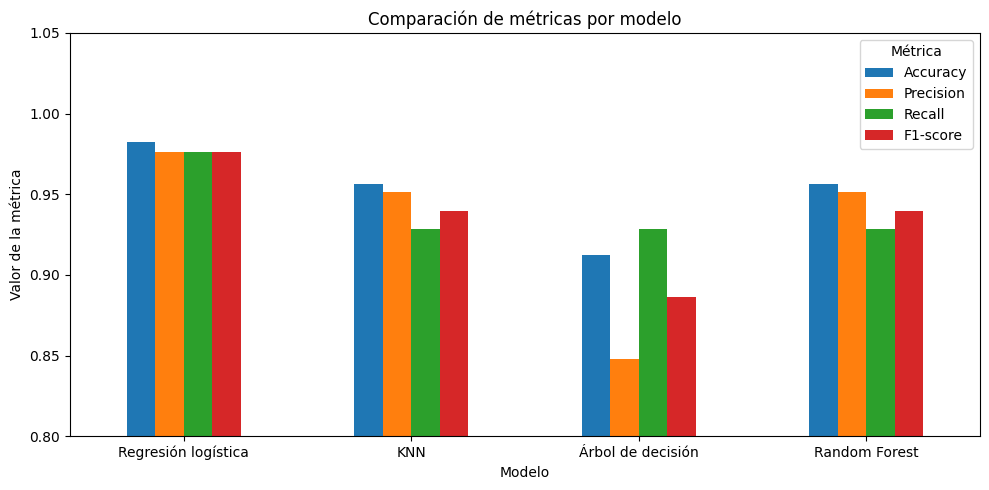

In [72]:
# Graficamos las métricas principales para comparar los modelos

metricas = ["Accuracy", "Precision", "Recall", "F1-score"]

df_resultados_grafico = df_resultados.set_index("Modelo")[metricas]

df_resultados_grafico.plot(kind="bar", figsize=(10, 5))

plt.title("Comparación de métricas por modelo")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.ylim(0.80, 1.05)
plt.xticks(rotation=0, ha="center")
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

El gráfico permite comparar las métricas de forma más visual.

La **regresión logística** se destaca como el modelo con mejor rendimiento general en esta primera evaluación. Sus valores son altos y equilibrados en todas las métricas.

**KNN** y **Random Forest** muestran un comportamiento muy similar entre sí. En esta ejecución, ambos obtuvieron los mismos valores en las métricas principales.

El **árbol de decisión** queda por debajo de los demás modelos, especialmente en `Precision`. Esto significa que, cuando predijo la clase maligna, cometió más errores que los otros modelos.

De todos modos, todavía estamos mirando los resultados sobre una única partición de entrenamiento y prueba. Para evaluar si estos resultados son estables, necesitamos usar **validación cruzada**.

## Validación cruzada

Hasta ahora evaluamos los modelos usando una única separación entre entrenamiento y prueba.

Ese procedimiento es útil, pero tiene una limitación: el resultado puede depender bastante de cómo quedaron divididos los datos. Si otra partición hubiera sido diferente, las métricas podrían cambiar.

Para obtener una estimación más estable del rendimiento, podemos usar **validación cruzada**.

La validación cruzada divide los datos de entrenamiento en varias partes, llamadas *folds*. Luego entrena y evalúa el modelo varias veces, usando distintas combinaciones de esos folds.

En este cuaderno vamos a usar `cross_val_score` para calcular el rendimiento de cada pipeline mediante validación cruzada.

Esto nos permitirá observar dos valores importantes:

- el rendimiento promedio del modelo;
- la variación entre las distintas particiones.

Un modelo no solo debería tener buen rendimiento, sino también ser relativamente estable.

In [73]:
# Calculamos validación cruzada para cada pipeline

resultados_cv = []

for nombre_modelo, pipeline in pipelines.items():

    # Calculamos los scores de validación cruzada
    # Usamos accuracy como métrica general para esta primera comparación de estabilidad.
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    # Guardamos el promedio y la desviación estándar
    resultados_cv.append(
        {
            "Modelo": nombre_modelo,
            "CV Accuracy promedio": scores.mean(),
            "CV Accuracy desvío": scores.std()
        }
    )

# Convertimos los resultados en un DataFrame
df_cv = pd.DataFrame(resultados_cv)

# Mostramos la tabla
df_cv

,Modelo,CV Accuracy promedio,CV Accuracy desvío
0,Regresión logística,0.980220,0.012815
1,KNN,0.967033,0.020850
2,Árbol de decisión,0.909890,0.018906
3,Random Forest,0.953846,0.023466


La validación cruzada nos da una mirada más estable del rendimiento de los modelos.

En este caso, la **regresión logística** obtiene el mejor promedio de `accuracy` en validación cruzada. Además, su desvío estándar es bajo, lo que indica que su rendimiento fue bastante consistente entre los distintos folds.

**KNN** también obtiene un buen resultado, aunque algo menor y con mayor variación.

**Random Forest** tiene un rendimiento promedio aceptable, pero en este caso queda por debajo de KNN y de la regresión logística.

El **árbol de decisión** vuelve a quedar por debajo del resto. Esto puede ocurrir porque un árbol individual suele ser más sensible a pequeñas variaciones en los datos de entrenamiento.

Esta comparación nos muestra algo importante: no alcanza con mirar el resultado de una sola división train/test. La validación cruzada nos ayuda a estimar si el modelo mantiene su rendimiento cuando cambian las particiones de los datos.

## Visualización de la validación cruzada

La tabla anterior nos muestra el promedio y el desvío estándar de la validación cruzada.

Ahora vamos a representar esos valores en un gráfico. El alto de cada barra indicará el rendimiento promedio del modelo, mientras que la línea de error mostrará la variación entre los folds.

Esto nos ayuda a comparar dos aspectos al mismo tiempo:

- qué modelo obtiene mejor rendimiento promedio;
- qué modelo parece más estable.

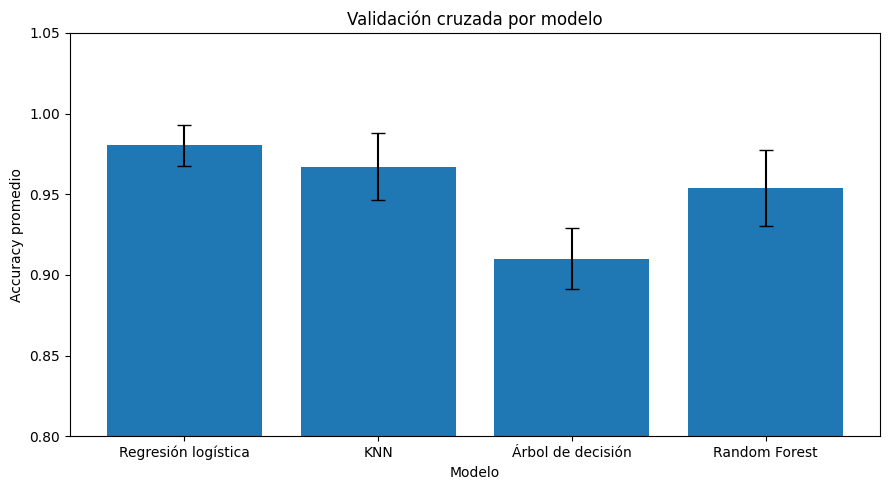

In [74]:
# Graficamos el promedio de accuracy en validación cruzada
# junto con su desviación estándar

plt.figure(figsize=(9, 5))

plt.bar(
    df_cv["Modelo"],
    df_cv["CV Accuracy promedio"],
    yerr=df_cv["CV Accuracy desvío"],
    capsize=5
)

plt.title("Validación cruzada por modelo")
plt.xlabel("Modelo")
plt.ylabel("Accuracy promedio")
plt.ylim(0.8, 1.05)
plt.xticks(rotation=0, ha="center")
plt.tight_layout()
plt.show()

El gráfico confirma visualmente lo que vimos en la tabla.

La **regresión logística** tiene el mejor rendimiento promedio en validación cruzada y, además, muestra una variación baja entre folds.

Esto refuerza la idea de que no solo tuvo buenos resultados en la partición de prueba, sino que también parece ser un modelo estable para este dataset.

**KNN** y **Random Forest** también tienen buenos resultados, aunque algo menores. El **árbol de decisión** queda por debajo del resto, lo que sugiere que, en este problema particular, un árbol individual no logra generalizar tan bien como los otros modelos.

Aun así, todavía falta incorporar una herramienta muy importante para problemas de clasificación binaria: la **curva ROC** y el valor **AUC**.

## Curva ROC y AUC

En problemas de clasificación binaria, muchos modelos no solo pueden predecir una clase final, sino también una probabilidad asociada a cada clase.

Por ejemplo, en lugar de decir directamente:

```text
tumor maligno
```

un modelo puede estimar algo como:

```text
probabilidad de maligno: 0.87
probabilidad de benigno: 0.13
```

La **curva ROC** permite analizar cómo se comporta el modelo cuando cambiamos el umbral de decisión.

Por defecto, un modelo suele clasificar un caso según la clase con mayor probabilidad. Pero en algunos problemas podríamos querer ser más estrictos o más sensibles según el costo de los errores.

La curva ROC compara dos elementos:

* la tasa de verdaderos positivos;
* la tasa de falsos positivos.

El valor **AUC** resume esa curva en un solo número. Cuanto más cercano a `1`, mejor capacidad tiene el modelo para separar las clases.

### Una aclaración importante sobre la clase positiva

Muchas funciones de `scikit-learn` asumen que la clase positiva es `1`.

Sin embargo, en este dataset estamos prestando especial atención a la clase `0`, que representa los casos malignos.

Por eso, cuando calculemos la curva ROC y el AUC, vamos a usar la probabilidad de pertenecer a la clase `0`.

Esto es importante para que la interpretación sea coherente con el problema: queremos analizar qué tan bien cada modelo separa los casos malignos de los benignos.

In [75]:
# Calculamos el AUC para cada modelo usando la probabilidad de la clase 0

resultados_auc = []

for nombre_modelo, pipeline in pipelines.items():

    # Obtenemos las clases del modelo ya entrenado.
    # Esto nos permite ubicar correctamente la columna correspondiente a la clase 0.
    clases = pipeline.named_steps["modelo"].classes_
    indice_clase_0 = list(clases).index(0)

    # Obtenemos las probabilidades predichas para el conjunto de prueba
    probabilidades = pipeline.predict_proba(X_test)

    # Nos quedamos con la probabilidad de pertenecer a la clase 0: tumor maligno
    probabilidad_maligno = probabilidades[:, indice_clase_0]

    # Convertimos y_test en una versión binaria donde:
    # 1 significa "maligno"
    # 0 significa "no maligno"
    y_test_maligno = (y_test == 0).astype(int)

    # Calculamos el AUC tomando como clase positiva a "maligno"
    auc = roc_auc_score(y_test_maligno, probabilidad_maligno)

    resultados_auc.append(
        {
            "Modelo": nombre_modelo,
            "AUC": auc
        }
    )

# Convertimos los resultados en un DataFrame
df_auc = pd.DataFrame(resultados_auc)

# Mostramos la tabla
df_auc

,Modelo,AUC
0,Regresión logística,0.995370
1,KNN,0.978836
2,Árbol de decisión,0.915675
3,Random Forest,0.993882


Los valores de AUC muestran qué tan bien cada modelo logra separar los casos malignos de los benignos usando sus probabilidades predichas.

En esta comparación, la **regresión logística** obtiene el AUC más alto, con un valor cercano a `1`. Esto indica una muy buena capacidad para distinguir entre ambas clases.

**Random Forest** también obtiene un AUC muy alto, casi igual al de la regresión logística. Esto significa que, aunque en algunas métricas anteriores no haya quedado primero, sus probabilidades predichas separan muy bien las clases.

**KNN** también presenta un buen AUC, aunque algo menor.

El **árbol de decisión** queda nuevamente por debajo del resto. Su AUC sigue siendo superior a `0.5`, por lo que no se comporta como un modelo aleatorio, pero su capacidad de separación es menor que la de los otros modelos.

Estos resultados refuerzan una idea importante: comparar modelos implica mirar varias señales al mismo tiempo. No alcanza con una sola métrica aislada.

## Visualización de las curvas ROC

Ahora vamos a graficar las curvas ROC de todos los modelos en una misma figura.

Este gráfico nos permite comparar visualmente la capacidad de cada modelo para separar las clases.

Una curva más cercana al ángulo superior izquierdo indica un mejor comportamiento. Además, agregaremos el valor AUC en la leyenda para facilitar la comparación.

Recordemos que, en este caso, vamos a tomar como clase positiva de análisis a los tumores malignos (`0`), porque son los casos que más nos interesa detectar correctamente.

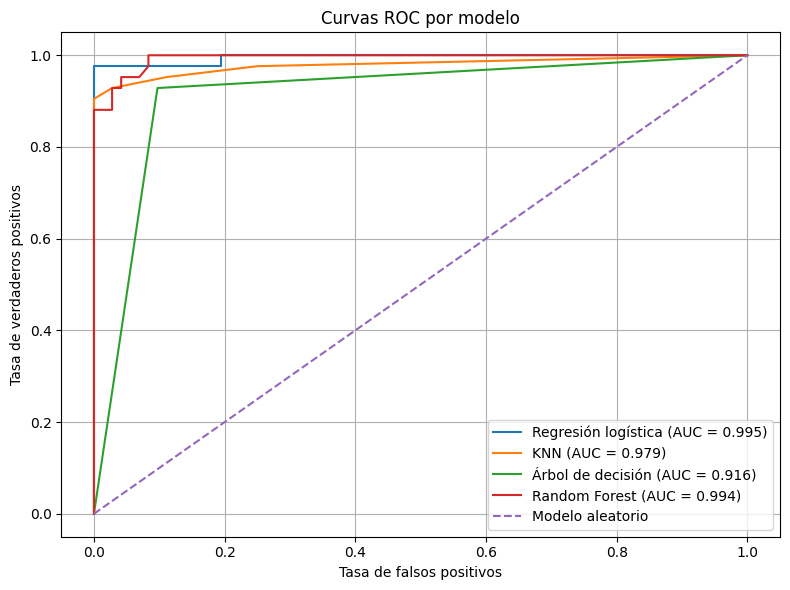

In [76]:
# Graficamos las curvas ROC de todos los modelos

plt.figure(figsize=(8, 6))

# Convertimos y_test para que la clase maligna sea considerada la clase positiva.
# 1 significa "maligno" y 0 significa "no maligno".
y_test_maligno = (y_test == 0).astype(int)

for nombre_modelo, pipeline in pipelines.items():

    # Obtenemos las clases del modelo entrenado
    clases = pipeline.named_steps["modelo"].classes_

    # Buscamos en qué columna de predict_proba está la probabilidad de la clase 0
    indice_clase_0 = list(clases).index(0)

    # Calculamos probabilidades para el conjunto de prueba
    probabilidades = pipeline.predict_proba(X_test)

    # Nos quedamos con la probabilidad de que el caso sea maligno
    probabilidad_maligno = probabilidades[:, indice_clase_0]

    # Calculamos los puntos de la curva ROC
    fpr, tpr, umbrales = roc_curve(y_test_maligno, probabilidad_maligno)

    # Calculamos el AUC
    auc = roc_auc_score(y_test_maligno, probabilidad_maligno)

    # Graficamos la curva del modelo
    plt.plot(fpr, tpr, label=f"{nombre_modelo} (AUC = {auc:.3f})")

# Línea de referencia de un modelo aleatorio
plt.plot([0, 1], [0, 1], linestyle="--", label="Modelo aleatorio")

plt.title("Curvas ROC por modelo")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

El gráfico de curvas ROC permite comparar visualmente la capacidad de separación de cada modelo.

La línea punteada representa un modelo aleatorio. Cuanto más cerca esté una curva del ángulo superior izquierdo, mejor será el comportamiento del modelo.

En este caso, la **regresión logística** y **Random Forest** tienen curvas muy cercanas al borde superior del gráfico y valores AUC muy altos. Esto indica que ambos modelos separan muy bien los casos malignos de los benignos.

**KNN** también muestra un buen desempeño, aunque con un AUC algo menor.

El **árbol de decisión** queda por debajo de los otros modelos. Su curva sigue estando claramente por encima de la línea aleatoria, pero muestra menor capacidad de separación.

Este gráfico confirma que la comparación de modelos no debería basarse en una única métrica. La regresión logística venía destacándose en las métricas básicas y en validación cruzada, mientras que Random Forest aparece muy competitivo cuando observamos el AUC.

## Tabla comparativa final

Ya calculamos varias métricas desde distintas perspectivas:

- métricas básicas sobre el conjunto de prueba;
- validación cruzada;
- AUC;
- análisis visual mediante matriz de confusión y curvas ROC.

Ahora vamos a reunir los principales resultados en una única tabla comparativa.

Esta tabla nos va a servir como base para tomar una decisión final y justificar qué modelo elegiríamos.

In [77]:
# Unimos las distintas tablas de resultados en una tabla comparativa final

df_comparacion_final = (
    df_resultados
    .merge(df_cv, on="Modelo")
    .merge(df_auc, on="Modelo")
)

# Ordenamos las columnas para facilitar la lectura
df_comparacion_final = df_comparacion_final[
    [
        "Modelo",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC",
        "CV Accuracy promedio",
        "CV Accuracy desvío"
    ]
]

# Mostramos la tabla comparativa final
df_comparacion_final

,Modelo,Accuracy,Precision,Recall,F1-score,AUC,CV Accuracy promedio,CV Accuracy desvío
0,Regresión logística,0.982456,0.976190,0.976190,0.976190,0.995370,0.980220,0.012815
1,KNN,0.956140,0.951220,0.928571,0.939759,0.978836,0.967033,0.020850
2,Árbol de decisión,0.912281,0.847826,0.928571,0.886364,0.915675,0.909890,0.018906
3,Random Forest,0.956140,0.951220,0.928571,0.939759,0.993882,0.953846,0.023466


La tabla comparativa final reúne las principales evidencias que obtuvimos durante el análisis.

La **regresión logística** aparece como el modelo más sólido en esta comparación:

- obtiene la mejor `Accuracy`;
- tiene la mejor `Precision`;
- tiene el mejor `Recall`;
- tiene el mejor `F1-score`;
- alcanza el valor más alto de `AUC`;
- también obtiene el mejor promedio en validación cruzada;
- presenta un desvío bajo entre folds.

Esto significa que no solo tuvo un buen rendimiento sobre el conjunto de prueba, sino que además mostró estabilidad en validación cruzada.

**Random Forest** también tiene un resultado muy competitivo, especialmente en `AUC`. Su capacidad para separar las clases es muy alta, aunque sus métricas sobre el conjunto de prueba y su promedio de validación cruzada quedaron por debajo de la regresión logística.

**KNN** ofrece un rendimiento general bueno, pero no supera a la regresión logística ni en las métricas principales ni en validación cruzada.

El **árbol de decisión** queda como el modelo menos conveniente en esta comparación. Tiene menor rendimiento general, menor AUC y una `Precision` más baja para la clase maligna.

A partir de esta tabla, la elección más razonable sería la **regresión logística**, al menos para esta primera versión del análisis.

## Toma de decisión: ¿qué modelo elegiríamos?

Después de comparar varios modelos, llega el momento de tomar una decisión.

En un proyecto real, elegir un modelo no debería ser una decisión automática ni basarse en una única métrica. La elección debe considerar el contexto del problema, el tipo de error que se quiere evitar, la estabilidad del modelo y la facilidad para explicar sus resultados.

En este caso, estamos trabajando con un problema vinculado a la detección de tumores malignos y benignos. Por eso, interesa especialmente que el modelo tenga buen rendimiento al identificar los casos malignos.

A partir de la comparación realizada, el modelo que elegiríamos es la **regresión logística**. Esta elección se justifica por varios motivos:

* En primer lugar, fue el modelo con mejores métricas sobre el conjunto de prueba: obtuvo la mayor `Accuracy`, `Precision`, `Recall` y `F1-score`. Esto indica que tuvo un rendimiento general alto y, además, logró detectar correctamente la mayoría de los casos malignos.

* En segundo lugar, también obtuvo el mejor resultado promedio en validación cruzada, con un desvío estándar bajo. Esto sugiere que su rendimiento no depende solamente de una partición particular de los datos, sino que se mantiene estable en distintas divisiones del conjunto de entrenamiento.

* Además, su valor de `AUC` fue el más alto entre los modelos comparados. Esto indica una muy buena capacidad para separar los casos malignos de los benignos a partir de las probabilidades predichas.

* Otro punto a favor es su interpretabilidad. La regresión logística suele ser más fácil de explicar que modelos más complejos como Random Forest. En problemas sensibles, donde no solo importa predecir bien sino también poder justificar el comportamiento del modelo, esta característica puede ser muy valiosa.

Random Forest también mostró un desempeño muy competitivo, especialmente en AUC, por lo que podría considerarse como una alternativa fuerte. Sin embargo, en esta comparación quedó por debajo de la regresión logística en las métricas principales y en validación cruzada.

Por estos motivos, para esta primera versión del análisis, la regresión logística aparece como la opción más equilibrada entre rendimiento, estabilidad e interpretabilidad.

## Limitaciones del análisis

Aunque la comparación realizada permite tomar una decisión razonable, es importante reconocer algunas limitaciones.

* En primer lugar, trabajamos con un dataset relativamente pequeño y ordenado. En problemas reales, los datos suelen presentar más dificultades: valores faltantes, columnas categóricas, errores de carga, variables irrelevantes o desbalance más marcado entre clases.

* En segundo lugar, los modelos fueron utilizados con configuraciones simples. No realizamos una búsqueda exhaustiva de hiperparámetros. Es posible que algunos modelos, como KNN, árbol de decisión o Random Forest, mejoren su rendimiento si se ajustan sus parámetros.

* En tercer lugar, el análisis se centró en métricas generales de clasificación. En un problema sensible, también podría ser necesario ajustar el umbral de decisión para reducir ciertos errores, especialmente los casos malignos clasificados como benignos.

* Por último, estos resultados no deben interpretarse como una herramienta médica real. El objetivo del análisis es comprender el proceso de comparación de modelos y practicar una toma de decisión fundamentada.

----

## Buenas prácticas al comparar modelos

Al comparar modelos de Machine Learning, conviene tener en cuenta algunas buenas prácticas:

- Usar la misma separación de datos para todos los modelos.
- Aplicar el mismo criterio de preprocesamiento cuando corresponda.
- Evitar ajustar transformaciones usando el conjunto de prueba.
- No elegir un modelo solamente por `accuracy`.
- Observar qué tipo de errores comete cada modelo.
- Usar validación cruzada para estimar estabilidad.
- Considerar métricas adecuadas al problema.
- Tener en cuenta la interpretabilidad y la complejidad del modelo.
- Justificar la elección final con evidencia, no solo con preferencia personal.

Los pipelines ayudan a sostener varias de estas prácticas, porque permiten encapsular el preprocesamiento y el modelo dentro de una misma estructura ordenada.

----

## ¿Cómo seguir?

A partir del análisis realizado, se puede continuar explorando el problema con alguna de las siguientes modificaciones:

1. Agregar otro modelo de clasificación y compararlo con los anteriores.
2. Modificar algún hiperparámetro de KNN, árbol de decisión o Random Forest.
3. Cambiar la métrica usada en la validación cruzada.
4. Analizar qué ocurre si se toma como prioridad maximizar el `Recall` de la clase maligna.
5. Investigar cómo cambiaría la decisión final si se eligiera el modelo solamente por AUC.
6. Redactar una nueva justificación técnica indicando qué modelo se elegiría y por qué.

La respuesta debería incluir no solo los resultados numéricos, sino también una breve interpretación de lo observado.

----

## Cierre

En este cuaderno se trabajó el proceso de comparación y evaluación de modelos de clasificación.

Primero se preparó un flujo de trabajo ordenado utilizando pipelines. Luego se entrenaron distintos modelos bajo condiciones equivalentes y se evaluaron con varias herramientas: métricas de clasificación, matriz de confusión, validación cruzada, curva ROC y AUC.

El análisis mostró que comparar modelos no consiste simplemente en buscar el número más alto en una tabla. Cada métrica responde una pregunta diferente y permite observar una parte distinta del comportamiento del modelo.

También vimos que la decisión final debe considerar el contexto del problema. En este caso, detectar correctamente los tumores malignos era especialmente importante, por lo que métricas como `Recall`, `F1-score`, matriz de confusión y AUC resultaron fundamentales.

Finalmente, la regresión logística apareció como la alternativa más equilibrada para esta versión del análisis, combinando buen rendimiento, estabilidad e interpretabilidad.